## EDA

### Import libraries

In [1]:
from ucimlrepo                import fetch_ucirepo 
import matplotlib.pyplot as plt
import seaborn  as sns
import numpy    as np
import pandas   as pd
from  xgboost                 import XGBClassifier
from  sklearn.model_selection import train_test_split
from sklearn.metrics          import classification_report, roc_auc_score
from lime.lime_tabular        import LimeTabularExplainer
from sklearn.model_selection  import cross_val_score
import optuna
import shap
from lime.lime_tabular        import LimeTabularExplainer

import os
from groq                     import Groq
from sklearn.metrics          import roc_auc_score
from reportlab.lib.pagesizes  import letter
from reportlab.lib.styles     import getSampleStyleSheet
from reportlab.platypus       import SimpleDocTemplate, Paragraph, Spacer
from dotenv                   import load_dotenv


### Loading dataset 

In [2]:

diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 


X  = diabetes_130_us_hospitals_for_years_1999_2008

X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 


c:\Users\USER\envs\mlenv\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


### Explore Features 

In [3]:
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [4]:
X.shape 

(101766, 47)

In [5]:
X.info()                                                                

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      99493 non-null   str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    3197 non-null    str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                61510 non-null   str  
 9   medical_specialty         51817 non-null   str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [6]:
X.nunique()

race                          5
gender                        3
age                          10
weight                        9
admission_type_id             8
discharge_disposition_id     26
admission_source_id          17
time_in_hospital             14
payer_code                   17
medical_specialty            72
num_lab_procedures          118
num_procedures                7
num_medications              75
number_outpatient            39
number_emergency             33
number_inpatient             21
diag_1                      716
diag_2                      748
diag_3                      789
number_diagnoses             16
max_glu_serum                 3
A1Cresult                     3
metformin                     4
repaglinide                   4
nateglinide                   4
chlorpropamide                4
glimepiride                   4
acetohexamide                 2
glipizide                     4
glyburide                     4
tolbutamide                   2
pioglita

-------------------------------------

### Checking class imbalance

In [7]:
y.notnull().sum()

readmitted    101766
dtype: int64

In [8]:
readmitted_counts = y.value_counts()
readmitted_percentages = readmitted_counts / len(X) * 100
print(readmitted_counts,'\n',readmitted_percentages)


readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64 
 readmitted
NO            53.911916
>30           34.928169
<30           11.159916
Name: count, dtype: float64


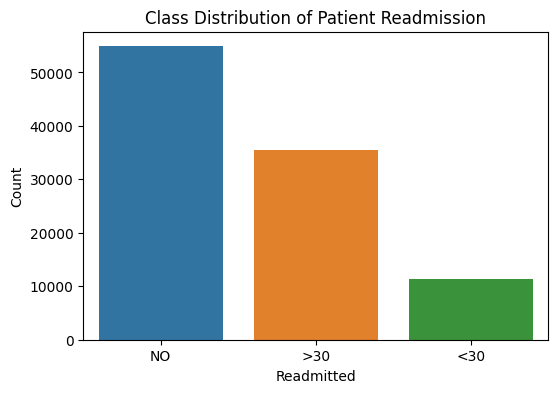

In [9]:
readmitted = readmitted_counts.reset_index()
readmitted.columns = ['Readmitted', 'Count']

plt.figure(figsize=(6, 4))
ax = sns.barplot(data= readmitted,
                 x='Readmitted',
                 y='Count',
                 hue='Readmitted')

plt.title('Class Distribution of Patient Readmission')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

----------------------

### Cleaning Dataset

-----------

In [10]:
# weight,
# max_glu_serum,
# A1Cresult ,
# payer_code,
# medical_specialty

In [11]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      99493 non-null   str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    3197 non-null    str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                61510 non-null   str  
 9   medical_specialty         51817 non-null   str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [12]:
df = pd.concat([X,y],axis = 1)
df.drop_duplicates(inplace=True)

-------------

In [13]:
X.drop(labels=['weight','payer_code'],axis=1 , inplace=True)

-----------------

In [14]:
X.max_glu_serum.value_counts()

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

In [15]:
glu_map = { np.nan:0,
           'Norm':1,
           '>200':2 ,
           '>300':3}

X['max_glu_serum'] = X['max_glu_serum'].map(glu_map)
X['max_glu_serum'].value_counts()

max_glu_serum
0    96420
1     2597
2     1485
3     1264
Name: count, dtype: int64

----------------

In [16]:
X.A1Cresult.value_counts()

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

In [17]:
a1c_map = {np.nan: 0, 
           'Norm': 5, 
           '>7': 7, 
           '>8': 8}
X['A1Cresult'] = X['A1Cresult'].map(a1c_map)
X['A1Cresult'].value_counts()

A1Cresult
0    84748
8     8216
5     4990
7     3812
Name: count, dtype: int64

-----------

In [18]:
X['medical_specialty'] = X['medical_specialty'].fillna('Unknown')


-----------------------

In [19]:
# race 
# diag_1 
# diag_2
# diag_3                                       

In [20]:
X['race'] = X['race'].fillna('Unknown')
print(X.race.value_counts())

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


---------------

In [21]:
# set(X.diag_1.unique())
# set(X.diag_2.unique())
# set(X.diag_3.unique())

In [22]:

def categorize_diagnostic(value):
    value  = str(value).upper()
    if value.startswith('V') : return 'Health_Status'
    if value.startswith('E') : return 'External_Injury' 

    try:
        code = float(value.split('.')[0])
        if 390 <= code <= 459 or code == 785: return 'Circulatory'
        if 460 <= code <= 519 or code == 786: return 'Respiratory'
        if 520 <= code <= 579 or code == 787: return 'Digestive'
        if 250 <= code < 251:                 return 'Diabetes'
        if 800 <= code <= 999:                return 'Injury'
        if 710 <= code <= 739:                return 'Musculoskeletal'
        if 580 <= code <= 629 or code == 788: return 'Genitourinary'
        if 140 <= code <= 239:                return 'Neoplasms'
        
        return 'Other_Medical'
    except:
        return 'Unknown'


for  i  in ['diag_1','diag_2','diag_3']:
    X[i] = X[i].apply(categorize_diagnostic)

In [23]:
X.drop(columns=['examide', 'citoglipton'],inplace=True)

In [24]:
len(X.columns)

43

----------------------

In [25]:
X.acetohexamide.value_counts()

acetohexamide
No        101765
Steady         1
Name: count, dtype: int64

In [26]:
X.tolbutamide.value_counts()

tolbutamide
No        101743
Steady        23
Name: count, dtype: int64

In [27]:
X.troglitazone.value_counts()

troglitazone
No        101763
Steady         3
Name: count, dtype: int64

In [28]:
X.medical_specialty.nunique()

73

In [29]:
X['glipizide-metformin'].value_counts()

glipizide-metformin
No        101753
Steady        13
Name: count, dtype: int64

In [30]:
X['glimepiride-pioglitazone'].value_counts()

glimepiride-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64

In [31]:
X['metformin-rosiglitazone'].value_counts()

metformin-rosiglitazone
No        101764
Steady         2
Name: count, dtype: int64

In [32]:
X['metformin-pioglitazone'].value_counts()

metformin-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64

In [33]:
X.drop(columns=['acetohexamide', 'tolbutamide','troglitazone','medical_specialty'],inplace=True)
X.drop(columns=['glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'],inplace=True)

### Encoding 

#### Features

In [34]:
for i  in X.columns:
    print({i:set(X[i].unique())})

{'race': {'Caucasian', 'Asian', 'AfricanAmerican', 'Hispanic', 'Other', 'Unknown'}}
{'gender': {'Male', 'Female', 'Unknown/Invalid'}}
{'age': {'[50-60)', '[90-100)', '[40-50)', '[60-70)', '[80-90)', '[10-20)', '[0-10)', '[30-40)', '[20-30)', '[70-80)'}}
{'admission_type_id': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}}
{'discharge_disposition_id': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28)}}
{'admission_source_id': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(17), np.int64(20), np.int

Gender

In [35]:
X['gender'] = X['gender'].replace('Unknown/Invalid', np.nan)
X['gender'].fillna(X['gender'].mode()[0], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_27328\1544243546.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X['gender'].fillna(X['gender'].mode()[0], inplace=True)


0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
101761      Male
101762    Female
101763      Male
101764    Female
101765      Male
Name: gender, Length: 101766, dtype: str

Age

In [36]:
age_map = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6,
    '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}
X['age'] = X['age'].map(age_map)

Change /  DiabetesMed

In [37]:

X['change'] = X['change'].map({'No': 0, 'Ch': 1})
X['diabetesMed'] = X['diabetesMed'].map({'No': 0, 'Yes': 1})

Drugs

In [38]:
drug_map = {
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': 3
}

drug_cols = [
    'metformin', 'glimepiride', 'glipizide', 'glyburide',
    'pioglitazone', 'rosiglitazone', 'insulin',
    'glyburide-metformin','repaglinide', 'nateglinide', 
    'chlorpropamide', 'acarbose','miglitol','tolazamide'
]

for col in drug_cols:
    X[col] = X[col].map(drug_map)

In [39]:
categorical_cols = [
                        'race',
                        'gender',
                        'diag_1',
                        'diag_2',
                        'diag_3',
                    ]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [40]:
X = pd.get_dummies(X, columns=['admission_type_id','discharge_disposition_id','admission_source_id' ])

In [41]:
bool_colms= X.select_dtypes(include='bool').columns
X[bool_colms] = X[bool_colms].astype(int)

In [42]:
for i  in X.columns:
    print({i:set(X[i].unique())})

{'age': {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}}
{'time_in_hospital': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}}
{'num_lab_procedures': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.in

#### Target  feature 

In [43]:
y.value_counts()

readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64

In [44]:
y['readmitted'] = y['readmitted'].apply( lambda x: 1 if x == '<30' else 0)

In [45]:
y.value_counts()

readmitted
0             90409
1             11357
Name: count, dtype: int64

## XGBoost  

In [46]:
X

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,...,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25
0,0,1,41,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,3,59,0,18,0,0,0,9,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2,11,5,13,2,0,1,6,0,...,0,0,0,0,0,0,0,0,0,0
3,3,2,44,1,16,0,0,0,7,0,...,0,0,0,0,0,0,0,0,0,0
4,4,1,51,0,8,0,0,0,5,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,7,3,51,0,16,0,0,0,9,0,...,0,0,0,0,0,0,0,0,0,0
101762,8,5,33,3,18,0,0,1,9,0,...,0,0,0,0,0,0,0,0,0,0
101763,7,1,53,0,9,1,0,0,13,0,...,0,0,0,0,0,0,0,0,0,0
101764,8,10,45,2,21,0,0,1,9,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
for i  in X.columns:
    print({i:set(X[i].unique())})

{'age': {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}}
{'time_in_hospital': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}}
{'num_lab_procedures': {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.in

In [48]:
X_train, X_test,y_train,y_test = train_test_split( X, y, test_size = 0.3 , random_state= 42 , stratify=y) 

In [49]:
scale_pos_weights = (y==0).sum() / (y==1).sum()
scale_pos_weights = scale_pos_weights.values[0]

### (Optional)  HyperParametr Tuning with Optuna 

In [50]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 4, 15), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15), 
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2
        'scale_pos_weight': scale_pos_weights 
    }

    model = XGBClassifier(**param, n_jobs=-1, random_state=42, use_label_encoder=False,)
    
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print("Ən yaxşı AUC score:",   study.best_value)
print("Ən yaxşı parametrlər:", study.best_params)

[I 2026-04-09 18:10:08,976] A new study created in memory with name: no-name-84c0f4b2-940a-4335-ace0-e6581db9ced5
c:\Users\USER\envs\mlenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\USER\envs\mlenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\USER\envs\mlenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\USER\envs\mlenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:15] WARNING: C:\actions-run

Ən yaxşı AUC score: 0.6755854751991461
Ən yaxşı parametrlər: {'n_estimators': 249, 'max_depth': 5, 'learning_rate': 0.04673792797405781, 'subsample': 0.9210629286532023, 'colsample_bytree': 0.6059197342365945, 'gamma': 0.007755280734276013, 'min_child_weight': 12, 'reg_alpha': 7.462294088392156e-06, 'reg_lambda': 0.06697146182817645}


In [51]:
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weights 

model = XGBClassifier(**best_params, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# Proqnozlar
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

In [52]:
importances  = model.feature_importances_
feature_names  = X_train.columns
 
feature_importance_df = pd.DataFrame({'feature':feature_names, 'importance':importances}).sort_values(by='importance',ascending=False)
feature_importance_df

,feature,importance
7,number_inpatient,0.079575
71,discharge_disposition_id_1,0.069291
81,discharge_disposition_id_11,0.053221
91,discharge_disposition_id_22,0.041212
6,number_emergency,0.023734
...,...,...
107,admission_source_id_11,0.000000
109,admission_source_id_14,0.000000
111,admission_source_id_20,0.000000
112,admission_source_id_22,0.000000


In [53]:
threshold = 0.01
new_features = feature_importance_df[feature_importance_df['importance']>threshold]
new_features = new_features['feature'].values
new_features

<StringArray>
[           'number_inpatient',  'discharge_disposition_id_1',
 'discharge_disposition_id_11', 'discharge_disposition_id_22',
            'number_emergency',  'discharge_disposition_id_3',
        'diag_1_Health_Status',  'discharge_disposition_id_5',
      'diag_1_Musculoskeletal',  'discharge_disposition_id_2',
          'diag_1_Respiratory',  'discharge_disposition_id_6',
 'discharge_disposition_id_13',                 'diabetesMed',
         'admission_type_id_6', 'discharge_disposition_id_28',
            'diag_2_Neoplasms',            'number_diagnoses',
        'diag_2_Health_Status',        'diag_1_Other_Medical']
Length: 20, dtype: str

In [54]:
X_train_new = X_train[new_features]
X_test_new = X_test[new_features]

model.fit(X_train_new,y_train)
y_pred = model.predict(X_test_new)
y_prob = model.predict_proba(X_test_new)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77     27123
           1       0.18      0.59      0.27      3407

    accuracy                           0.65     30530
   macro avg       0.55      0.62      0.52     30530
weighted avg       0.84      0.65      0.71     30530

ROC-AUC: 0.6721563500829218


## SHAP

In [55]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_new)

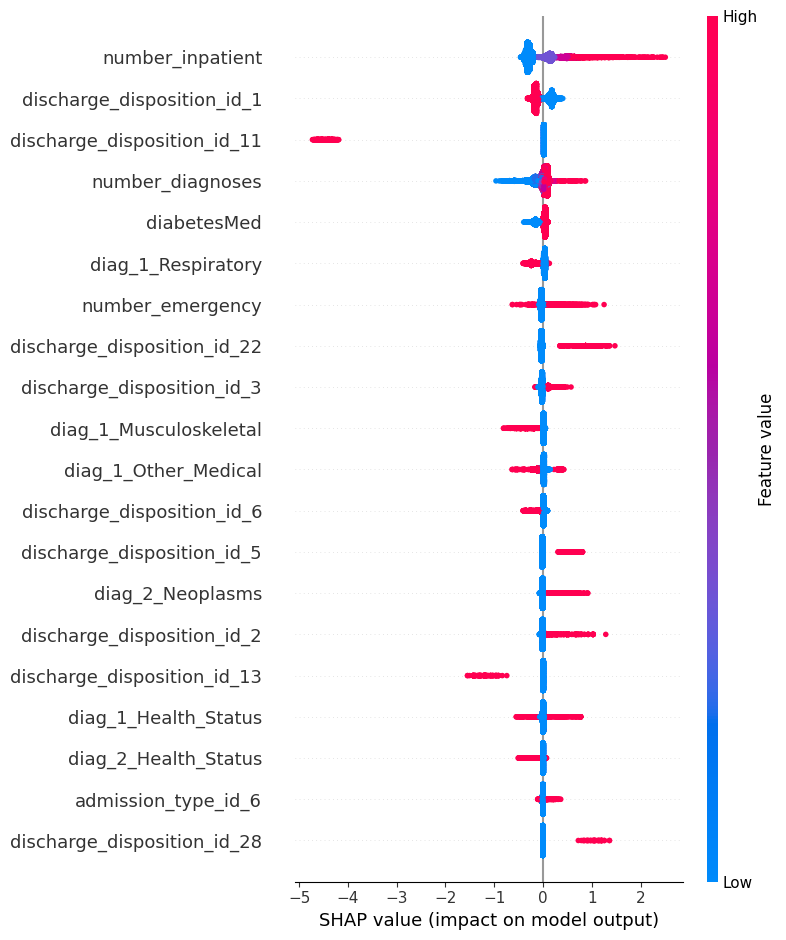

In [56]:
shap.summary_plot(shap_values, X_test_new) #  global +  direction

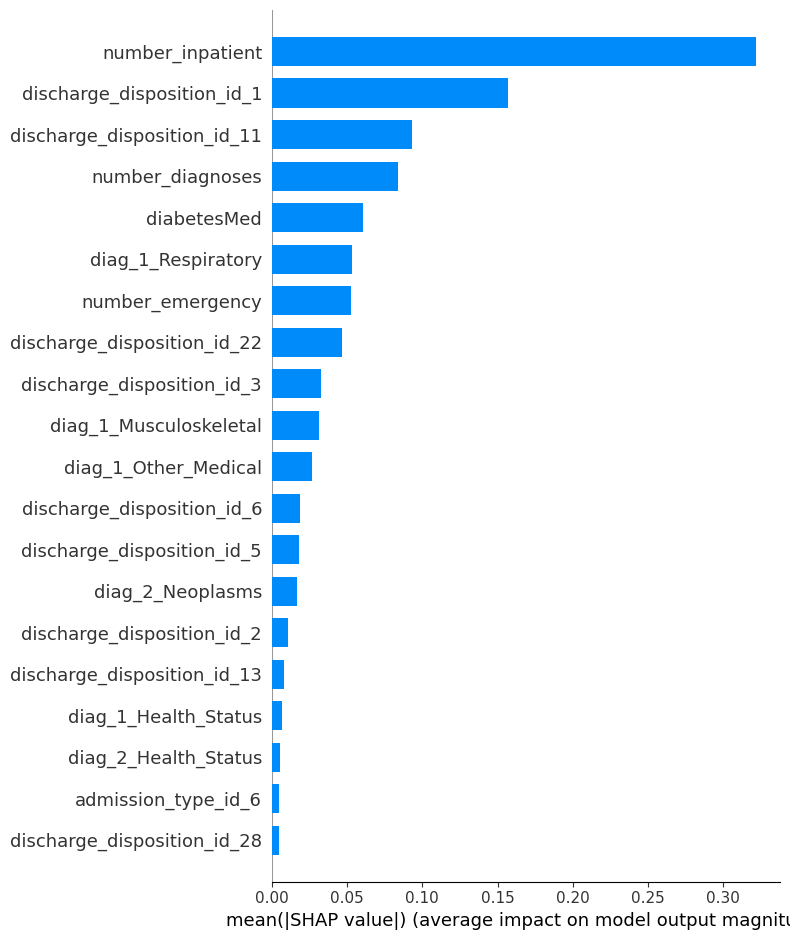

In [57]:
shap.summary_plot(shap_values, X_test_new, plot_type="bar",max_display=20)
# importance

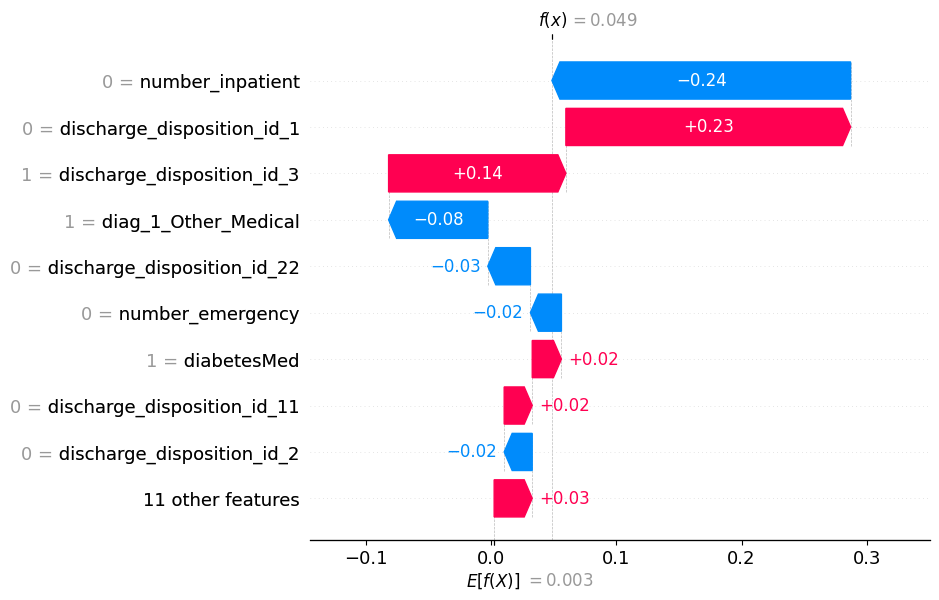

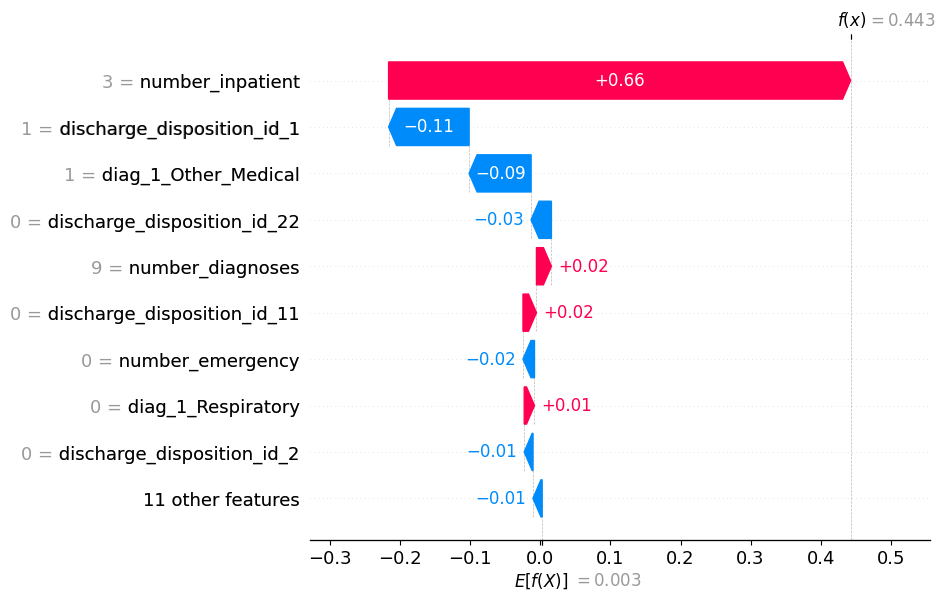

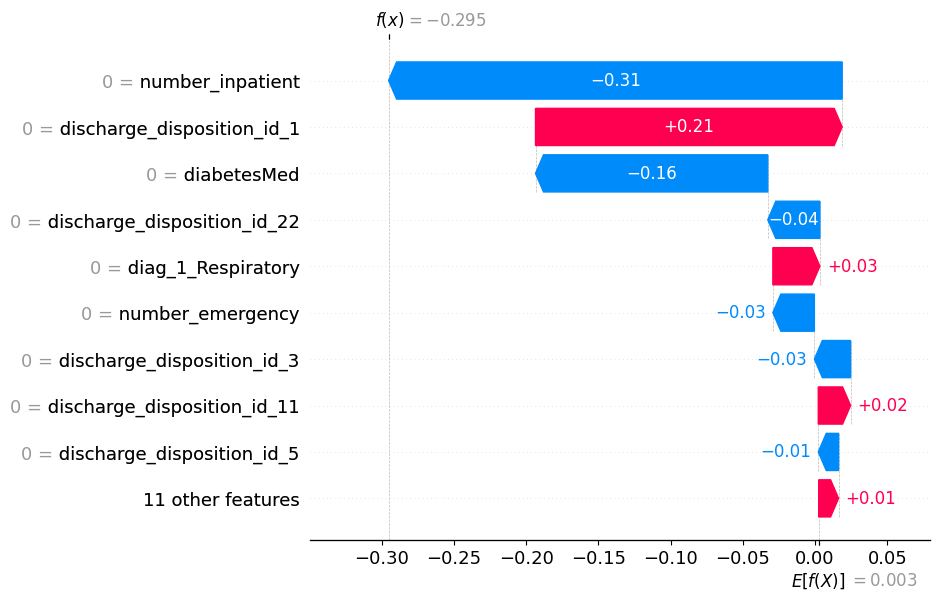

In [58]:
for i in  range(3):
    shap.plots.waterfall(shap.Explanation(shap_values[i], 
                                        base_values= explainer.expected_value, 
                                        data=X_test_new.iloc[i]))
# local

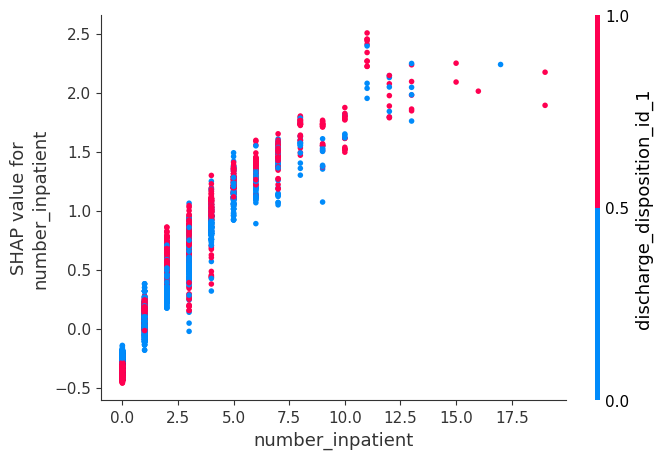

In [59]:
shap.dependence_plot('number_inpatient', shap_values, X_test_new)
# relationship

## LIME

In [60]:
lime_explainer = LimeTabularExplainer(
                                        training_data=np.array(X_train_new.values),
                                        feature_names=X_train_new.columns,
                                        class_names=['No Readmit', 'Readmit'],
                                        mode='classification'
                                    )

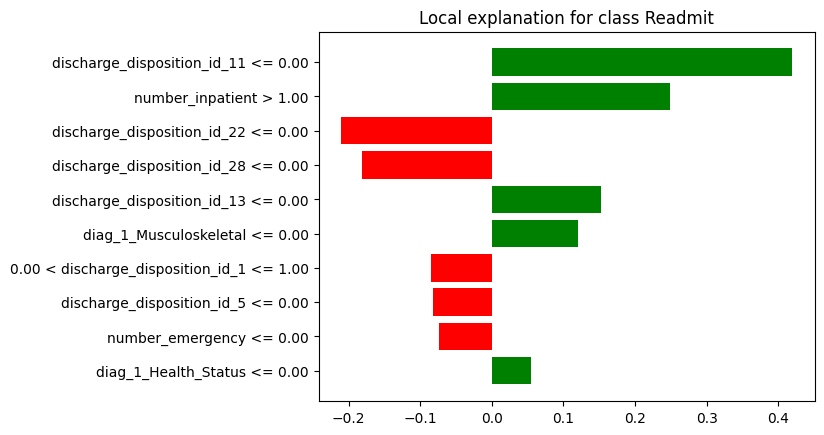

In [61]:
exp = lime_explainer.explain_instance(
                                        X_test_new.iloc[1].values,
                                        model.predict_proba,
                                        num_features=10
                                    )

exp.as_pyplot_figure();

In [ ]:
import os
import re
import numpy as np
from groq import Groq
from sklearn.metrics import roc_auc_score
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

CLINICAL_MAPPING = {
    'discharge_disposition_id_11': 'Expired (Died)',
    'discharge_disposition_id_1': 'Discharged to home',
    'discharge_disposition_id_22': 'Transfer to specialized hospital',
    'diabetesMed': 'Diabetes Medication Prescription',
    'number_inpatient': 'Prior Hospital Admissions',
    'num_medications': 'Number of Prescribed Medications'
}

def analyze_and_report(model, X_test, y_test, y_prob, shap_values, lime_exp):
    auc_score = roc_auc_score(y_test, y_prob)
    
    if isinstance(shap_values, list):
        importances = np.abs(shap_values[1]).mean(0)
    else:
        importances = np.abs(shap_values).mean(0)
        
    raw_top_features = X_test.columns[np.argsort(importances)][-5:].tolist()
    clinical_top_features = [CLINICAL_MAPPING.get(f, f) for f in raw_top_features]
    main_feature = raw_top_features[-1]

    prompt = f"""
    You are a Senior Medical AI Consultant. Draft a professional clinical report based on these results:
    - Model: XGBoost Readmission Classifier
    - AUC Score: {auc_score:.2f}
    - Key Risk Factors (SHAP): {", ".join(clinical_top_features)}
    - Individual Case Details (LIME): {lime_exp.as_list()}

    Requirements:
    1. Translate technical IDs (like 'id_11') to clinical terms.
    2. Provide 3 actionable clinical recommendations.
    3. Discuss Fairness (regularization, audits).
    4. Interpret AUC for clinical decision-making.
    5. No UI text, no zoom mentions. Use professional headers.
    """

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.3-70b-versatile",
        temperature=0.1 # Daha ciddi və təkrarlanabilir nəticə üçün 0.1 tövsiyə olunur
    )
    
    analysis_result = chat_completion.choices[0].message.content
    generate_pdf_fixed(analysis_result)
    generate_note_md(auc_score, main_feature)
    print(f"Success! AUC: {auc_score:.2f}. Files 'medical_report.pdf' and 'note.md' updated.")

def generate_pdf_fixed(text):
    doc = SimpleDocTemplate("medical_report.pdf", pagesize=letter)
    styles = getSampleStyleSheet()
    story = []
    
    # Başlıq
    story.append(Paragraph("<b>Medical Analysis & Readmission Report</b>", styles['Title']))
    story.append(Spacer(1, 12))
    
    def safe_html_clean(t):
        # 1. Markdown qalın yazılarını HTML-ə çevir
        t = re.sub(r'\*\*(.*?)\*\*', r'<b>\1</b>', t)
        # 2. Xüsusi simvolların qorunması
        t = t.replace('&', '&amp;').replace('#', '')
        # 3. Teq balanslaşdırma (Xətanın qarşısını alan əsas hissə)
        open_tags = len(re.findall(r'<b>', t))
        close_tags = len(re.findall(r'</b>', t))
        if open_tags > close_tags:
            t += '</b>' * (open_tags - close_tags)
        return t.strip()

    lines = text.split('\n')
    for line in lines:
        if line.strip():
            cleaned_line = safe_html_clean(line)
            try:
                p = Paragraph(cleaned_line, styles['Normal'])
                story.append(p)
                story.append(Spacer(1, 4))
            except Exception:
                # Əgər hələ də xəta verərsə, teqləri tam silib yaz
                p = Paragraph(cleaned_line.replace('<b>','').replace('</b>',''), styles['Normal'])
                story.append(p)
                story.append(Spacer(1, 4))
    
    doc.build(story)

def generate_note_md(auc, top_feat):
    note_content = f"""# Project Summary
- Dataset of 70,000+ patient records from US hospitals
- XGBoost AUC: {auc:.2f}, most important feature: {top_feat}
- SHAP summary plot highlights severity and cost
- LIME applied to top 10 risk cases for individual explanation"""
    with open("note.md", "w") as f:
        f.write(note_content.strip())

# İcra
y_prob = model.predict_proba(X_test_new)[:, 1]
analyze_and_report(model, X_test_new, y_test, y_prob, shap_values, exp)

Success! AUC: 0.67. Files 'medical_report.pdf' and 'note.md' updated.
